# Testing the EDR and EFD Calculations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import orekit_jpype as orekit


orekit.initVM(jvmpath="C://Program Files//Eclipse Adoptium//jdk-17.0.18.8-hotspot//bin//server//jvm.dll",
              additional_classpaths=[r"D:\GitHub\contigo_edr\java_src\target\orekit_utils-1.0.0.jar"])



Need to set this up for timescales and what not

In [3]:
from orekit_jpype.pyhelpers import setup_orekit_data, download_orekit_data_curdir
#download_orekit_data_curdir()
setup_orekit_data(from_pip_library=False)

In [4]:
import pandas as pd
import numpy as np


from contigo.constellation import Constellation
from contigo.edr_efd import EDRDensity

# Ephemeris
from contigo.ephemeris.orekit_ephem import OrekitEphem
from contigo.ephemeris.spice_ephem import SPICEEphem
from contigo.solar_system_ephem import SolarSystemEnvironment

# Forces and acceleration
from contigo.forces.third_body_acc import ThirdBodyAcc
from contigo.forces.third_body_acc import ThirdBody
from contigo.forces.third_body_acc import ThirdBodyEnv
from contigo.forces.grav_pot import EarthPotential
from contigo.forces.srp_gmat import SRPAcc 
from contigo.forces.srp_orekit import SRPOrekitCB

In [5]:
sw_e = pd.read_hdf("./data/ESA_pod.hdf")
sw_o = pd.read_hdf("./data/ore_d.hdf")

print(sw_e.columns)
print(sw_o.columns)

Index(['index', 'sat', 'x', 'y', 'z', 'DateTime', 'vx', 'vy', 'vz',
       'EstSat.EarthFixed.X', 'EstSat.EarthFixed.Y', 'EstSat.EarthFixed.Z',
       'EstSat.EarthFixed.VX', 'EstSat.EarthFixed.VY', 'EstSat.EarthFixed.VZ',
       'EstSat.TAIGregorian', 'eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy',
       'eci_vz', 'eg_x', 'eg_y', 'eg_z', 'sg_x', 'sg_y', 'sg_z', 'mg_x',
       'mg_y', 'mg_z', 'srp_x', 'srp_y', 'srp_z'],
      dtype='str')
Index(['eci_x', 'eci_y', 'eci_z', 'eci_vx', 'eci_vy', 'eci_vz', 'eci_sn_ax',
       'eci_sn_ay', 'eci_sn_az', 'eci_mn_ax', 'eci_mn_ay', 'eci_mn_az',
       'ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az', 'ecef_mn_ax', 'ecef_mn_ay',
       'ecef_mn_az', 'ecef_sn_px', 'ecef_sn_py', 'ecef_sn_pz', 'ecef_mn_px',
       'ecef_mn_py', 'ecef_mn_pz', 'earth_gp', 'DateTime', 'ecef_x', 'ecef_y',
       'ecef_z', 'ecef_vx,', 'ecef_vy', 'ecef_vz', 'edr', 'denom'],
      dtype='str')


In [6]:
# create a Constellation object from the ESA POD file
# and calculate thirdbody acceleration from ThirdBody
hdf_sc = Constellation(state_file=r'D:\GitHub\contigo_edr\data\ESA_pod.hdf', 
                    time_col='DateTime', x_col='x', y_col='y', z_col='z',
                    vx_col='vx', vy_col='vy', vz_col='vz', 
                    sc_id_col='filename', sc_fn_slc=slice(-11,-8),
                    tscale_input='GPS', 
                    sc_mass=4.3e+02, cr=1.8, srp_area=1, cd=3.5, drag_area=1.1)

In [7]:
# setup the ephemeris provider we want
# and the solar system environement 
# which defines the tolerance for ephemeris cacheing and the bodies we want
# in our solar system
#ephem = SPICEEphem(ephemeris='de440s', frame='ITRF93', observer='EARTH')
ephem = OrekitEphem( )

env = SolarSystemEnvironment(bodies=['SUN','MOON'], tolerance=0.01, provider=ephem, 
                            ephem_time=hdf_sc.sspice_et, 
                            gps_time=hdf_sc.sspice_gps,
                            utc_time=hdf_sc.sc_utc)

In [8]:
# this is a big lmax but this is what 
# we use in the orekit derivation and
# is what we need here to for a comparison
ep = EarthPotential(lmax=100) 
tba = ThirdBody(body=['SUN','MOON'])
tba_env = ThirdBodyEnv( )
#srp = SRPAcc(apistartup="api_startup_file.txt", gmat_install="C:/Users/murph/GMAT_R2025a/")
srp = SRPOrekitCB( )

In [11]:
acc = tba.acceleration(hdf_sc)
acc_env = tba_env.acceleration(hdf_sc, env)
acc_ork = sw_o[['ecef_sn_ax', 'ecef_sn_ay', 'ecef_sn_az', 
                'ecef_mn_ax', 'ecef_mn_ay', 'ecef_mn_az']].to_numpy()
acc_ork = acc_ork/1000.

TypeError: SPICEEphem.__call__() got an unexpected keyword argument 'et'

In [ ]:
spos = sw_e[['x','y','z']].to_numpy()
stime = sw_e['DateTime']
tba_cont = ThirdBodyAcc(spos=spos,stime=stime.to_numpy(),body=['SUN','MOON'],scale='GPS')  
tba_cont.calc_tba()
tba_old = tba_cont.get_tba()

In [9]:
edr = EDRDensity(constellation=hdf_sc,
                 solarsys_env=env, force_models=[tba_env,srp],potential_model=ep)

In [17]:
acc_con = edr.compute_edr()

Derived accelerations for model ThirdBodyAcceleration
Derived accelerations for model SRPOrekitCannonball
Integrating accelerations for model ThirdBodyAcceleration
Integrating accelerations for model SRPOrekitCannonball


In [11]:
den_con = edr.compute_denom()

In [12]:
print(den_con['ESA'])
print(sw_o['denom'].to_numpy()/(1000**5))

print(np.allclose(den_con['ESA'],sw_o['denom'].to_numpy()/(1000**5)))

[0.00000000e+00 3.93727414e-05 7.87421533e-05 ... 5.42573426e+00
 5.42577318e+00 5.42581210e+00]
[0.00000000e+00 3.93727351e-05 7.87421406e-05 ... 5.42573426e+00
 5.42577318e+00 5.42581210e+00]
True


In [13]:
contigo = pd.DataFrame(acc_con['ESA'])

True


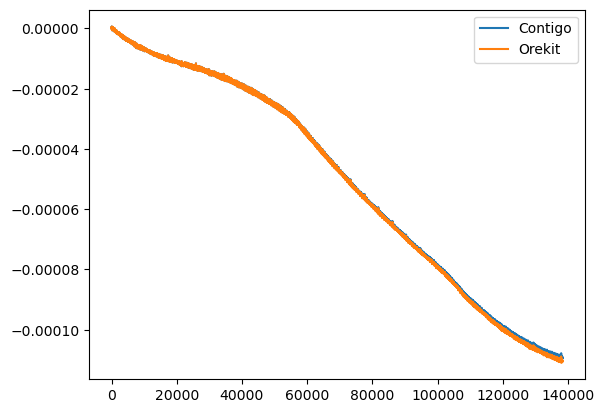

In [14]:
sw_o['edr_km'] = (sw_o['edr']-sw_o['edr'][0])/(1000**2)
ax = contigo['edr'].plot(label='Contigo')
sw_o['edr_km'].plot(ax=ax,label='Orekit')

ax.legend()

ac = np.allclose(sw_o['edr_km'].to_numpy(),contigo['edr'].to_numpy(),atol=1E-7,rtol=0.1)
print(ac)


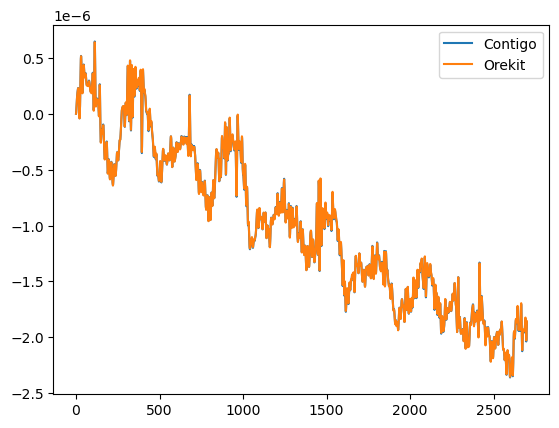

In [15]:
end = int(5*90*60/10)
ax = contigo['edr'][0:end].plot(label='Contigo')
sw_o['edr_km'][0:end].plot(ax=ax, label='Orekit')
ax.legend()
